# Actividad 1: Métodos de Kernel

> **Reto:** ¿Qué modelo utilizar para resolver diferentes tipos de problemas no lineales?

En esta actividad exploramos cómo los **métodos de kernel** permiten extender modelos lineales (como el SVM) para resolver problemas de clasificación donde los datos **no son separables linealmente** en su espacio original.

## Contenidos
1. [Fundamentos teóricos](#1-fundamentos-teóricos)
2. [Preparación del entorno](#2-preparación-del-entorno)
3. [Dataset sintético no lineal](#3-dataset-sintético-no-lineal)
4. [SVM con múltiples kernels](#4-svm-con-múltiples-kernels)
5. [Optimización de hiperparámetros](#5-optimización-de-hiperparámetros)
6. [Dataset real: Breast Cancer Wisconsin](#6-dataset-real-breast-cancer-wisconsin)
7. [Evaluación objetiva y métricas](#7-evaluación-objetiva-y-métricas)
8. [Conclusiones](#8-conclusiones)


## 1. Fundamentos teóricos

### ¿Por qué no basta un clasificador lineal?

Muchos problemas reales presentan fronteras de decisión **curvas o complejas**. Un hiperplano lineal no puede separar correctamente clases que se entrelazan en el espacio de características original.

### El truco del kernel

La idea central es **mapear los datos a un espacio de mayor dimensionalidad** donde sí sean linealmente separables, sin necesidad de calcular explícitamente esa transformación. Esto se logra mediante la **función de kernel** $K(x_i, x_j)$, que computa el producto interno en el espacio transformado de forma implícita.

#### Kernels comunes en SVM:

| Kernel | Fórmula | Característica |
|--------|---------|----------------|
| **Lineal** | $K(x, x') = x \cdot x'$ | Sin transformación; útil si los datos ya son separables |
| **RBF (Gaussiano)** | $K(x, x') = \exp(-\gamma \|x - x'\|^2)$ | Mapea a espacio infinito-dimensional; muy flexible |
| **Polinomial** | $K(x, x') = (\gamma \; x \cdot x' + r)^d$ | Captura interacciones polinómicas entre características |
| **Sigmoide** | $K(x, x') = \tanh(\gamma \; x \cdot x' + r)$ | Similar a una neurona; menos usado, sensible a params |

### Trade-off clave: $C$ vs $\gamma$
- **C (regularización):** penaliza errores de clasificación. Valores altos = menos tolerancia a errores (riesgo de sobreajuste).
- **Gamma ($\gamma$):** define el alcance de la influencia de un solo punto de entrenamiento. Valores altos = fronteras más "rizadas" (riesgo de sobreajuste).


## 2. Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

# Configuración global de estilo
sns.set_theme(style='whitegrid', palette='viridis')
alt.renderers.enable('default')
np.random.seed(42)


## 3. Dataset sintético no lineal

Usamos `make_moons` y `make_circles`, dos datasets clásicos que son **imposibles de separar linealmente** en $\mathbb{R}^2$.


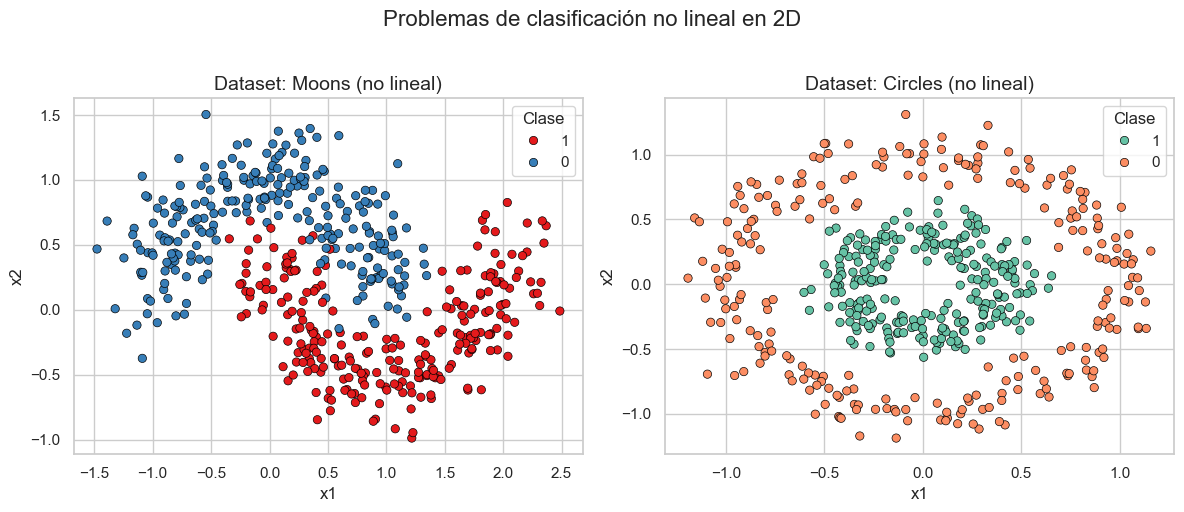

In [2]:
# Generamos ambos datasets
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=42)
X_circles, y_circles = make_circles(n_samples=500, noise=0.1, factor=0.4, random_state=42)

# Visualización conjunta con Seaborn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_moons = pd.DataFrame(X_moons, columns=['x1', 'x2'])
df_moons['clase'] = y_moons.astype(str)
sns.scatterplot(data=df_moons, x='x1', y='x2', hue='clase', ax=axes[0], palette='Set1', edgecolor='k')
axes[0].set_title('Dataset: Moons (no lineal)', fontsize=14)
axes[0].legend(title='Clase')

df_circles = pd.DataFrame(X_circles, columns=['x1', 'x2'])
df_circles['clase'] = y_circles.astype(str)
sns.scatterplot(data=df_circles, x='x1', y='x2', hue='clase', ax=axes[1], palette='Set2', edgecolor='k')
axes[1].set_title('Dataset: Circles (no lineal)', fontsize=14)
axes[1].legend(title='Clase')

plt.suptitle('Problemas de clasificación no lineal en 2D', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


> **Observación:** En ambos casos, cualquier recta que intente separar las clases cometerá errores sistemáticos. Aquí es donde el kernel entra en juego.

## 4. SVM con múltiples kernels

Entrenamos un clasificador SVM con cuatro kernels distintos sobre el dataset **Moons** y visualizamos las **fronteras de decisión**.


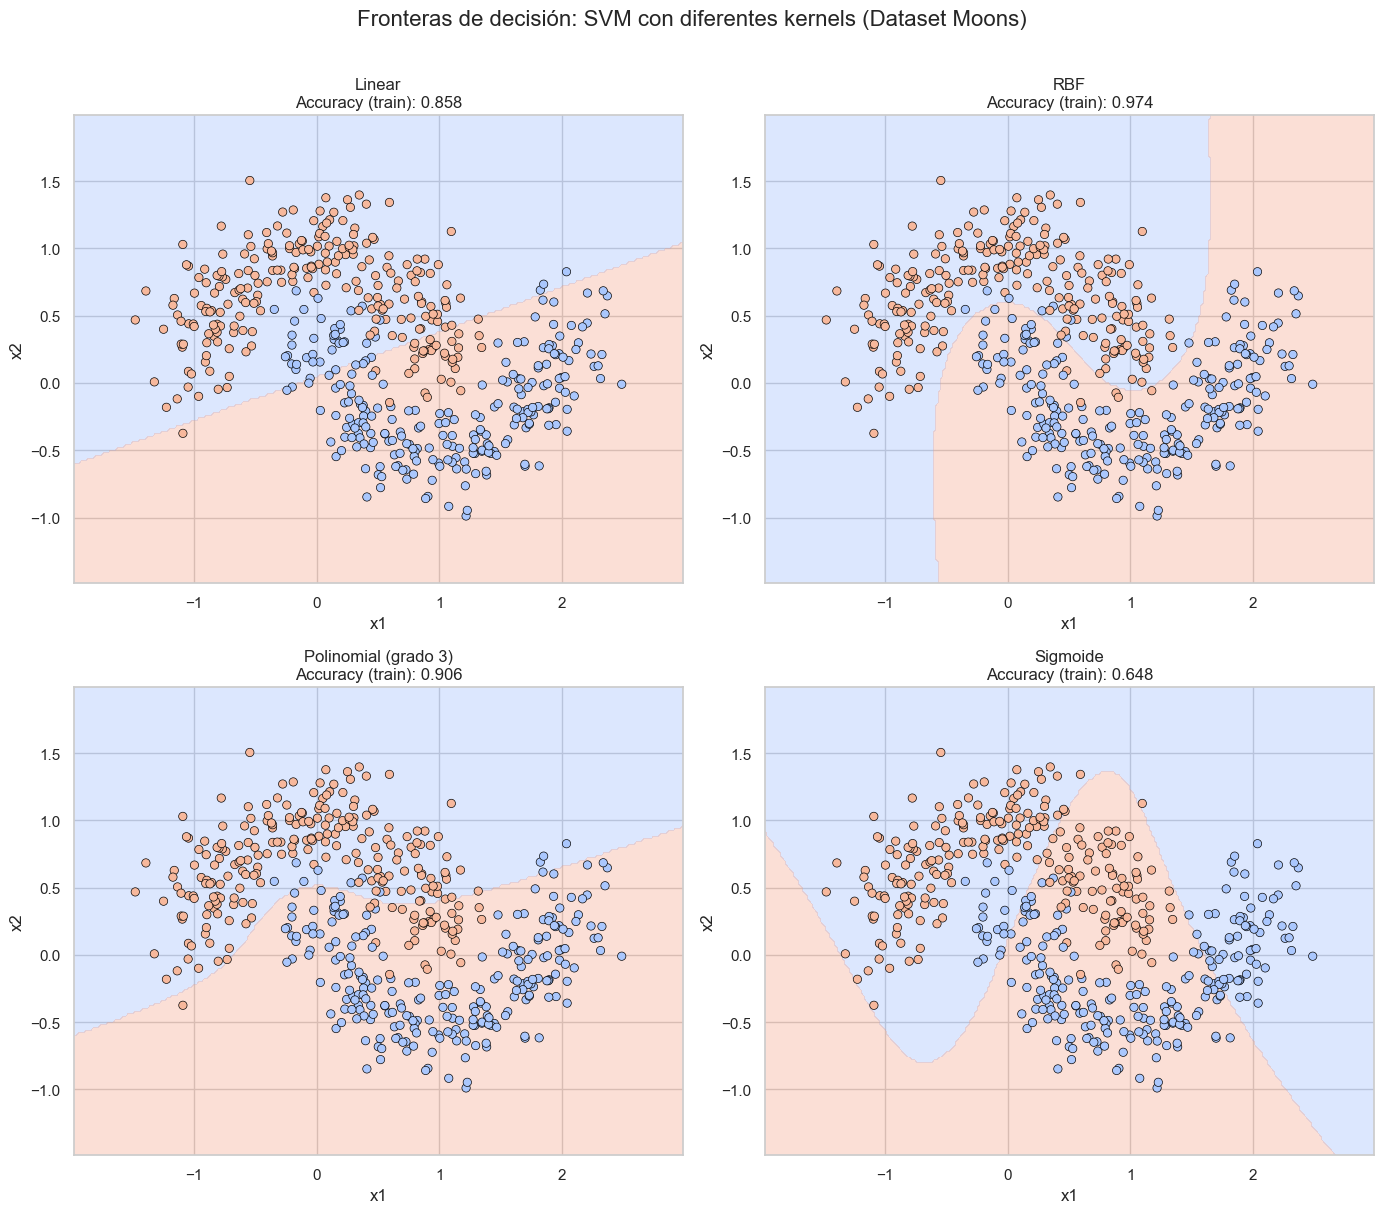

In [3]:
# Función auxiliar para graficar fronteras de decisión
def plot_decision_boundary(ax, X, y, model, title, cmap='viridis'):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap, levels=1)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y.astype(str),
                    palette=cmap, edgecolor='k', ax=ax, legend=False)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

# Diccionario de modelos con hiperparámetros base
kernels = {
    'Linear': SVC(kernel='linear', C=1.0),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale'),
    'Polinomial (grado 3)': SVC(kernel='poly', degree=3, C=1.0, gamma='scale'),
    'Sigmoide': SVC(kernel='sigmoid', C=1.0, gamma='scale')
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(kernels.items()):
    model.fit(X_moons, y_moons)
    acc = accuracy_score(y_moons, model.predict(X_moons))
    plot_decision_boundary(axes[idx], X_moons, y_moons, model,
                         f'{name}\nAccuracy (train): {acc:.3f}', cmap='coolwarm')

plt.suptitle('Fronteras de decisión: SVM con diferentes kernels (Dataset Moons)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


> **Análisis:** El kernel **lineal** falla rotundamente. El **RBF** y el **polinomial** adaptan fronteras curvas que resuelven el problema. El **sigmoide** puede ser inestable en datasets pequeños o con ruido.

## 5. Optimización de hiperparámetros

Usamos `GridSearchCV` para encontrar la combinación óptima de **C** y **gamma** con el kernel **RBF**, que suele ser el más versátil.


In [4]:
# División train/test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons
)

# Escalado (recomendable para SVM)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Grilla de búsqueda
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train_s, y_train)

print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'Mejores CV accuracy: {grid.best_score_:.4f}')


Mejores hiperparámetros: {'C': 10, 'gamma': 'scale'}
Mejores CV accuracy: 0.9800


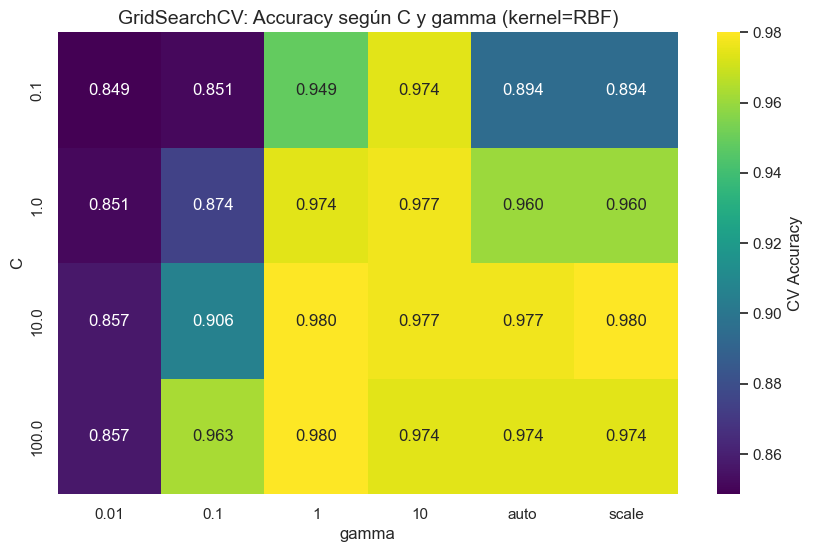

In [5]:
# Resultados de CV como DataFrame para visualización con Seaborn
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'CV Accuracy'})
plt.title('GridSearchCV: Accuracy según C y gamma (kernel=RBF)', fontsize=14)
plt.xlabel('gamma')
plt.ylabel('C')
plt.show()


## 6. Dataset real: Breast Cancer Wisconsin

Aplicamos lo aprendido a un problema médico real: clasificación de tumores de mama como benignos o malignos.

Este dataset tiene 30 características numéricas y es un benchmark clásico en machine learning. Es **limpio, balanceado y sin valores faltantes**, lo que permite enfocarnos directamente en el efecto de los kernels sin distraernos con preprocesamiento de baja calidad.


In [6]:
# Carga y exploración
data = load_breast_cancer()
X_bc = pd.DataFrame(data.data, columns=data.feature_names)
y_bc = pd.Series(data.target, name='target')

print('Dimensiones:', X_bc.shape)
print('Clases:', data.target_names)
print('Distribución de clases:')
print(y_bc.value_counts().rename(index={0: 'malignant', 1: 'benign'}))


Dimensiones: (569, 30)
Clases: ['malignant' 'benign']
Distribución de clases:
target
benign       357
malignant    212
Name: count, dtype: int64


In [7]:
# Preprocesamiento mínimo: solo escalado (SVM requiere features en la misma escala)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
X_train_bc_s = scaler_bc.fit_transform(X_train_bc)
X_test_bc_s = scaler_bc.transform(X_test_bc)


## 7. Evaluación objetiva y métricas

Entrenamos SVM con los cuatro kernels sobre el dataset real y reportamos múltiples métricas para una evaluación rigurosa.


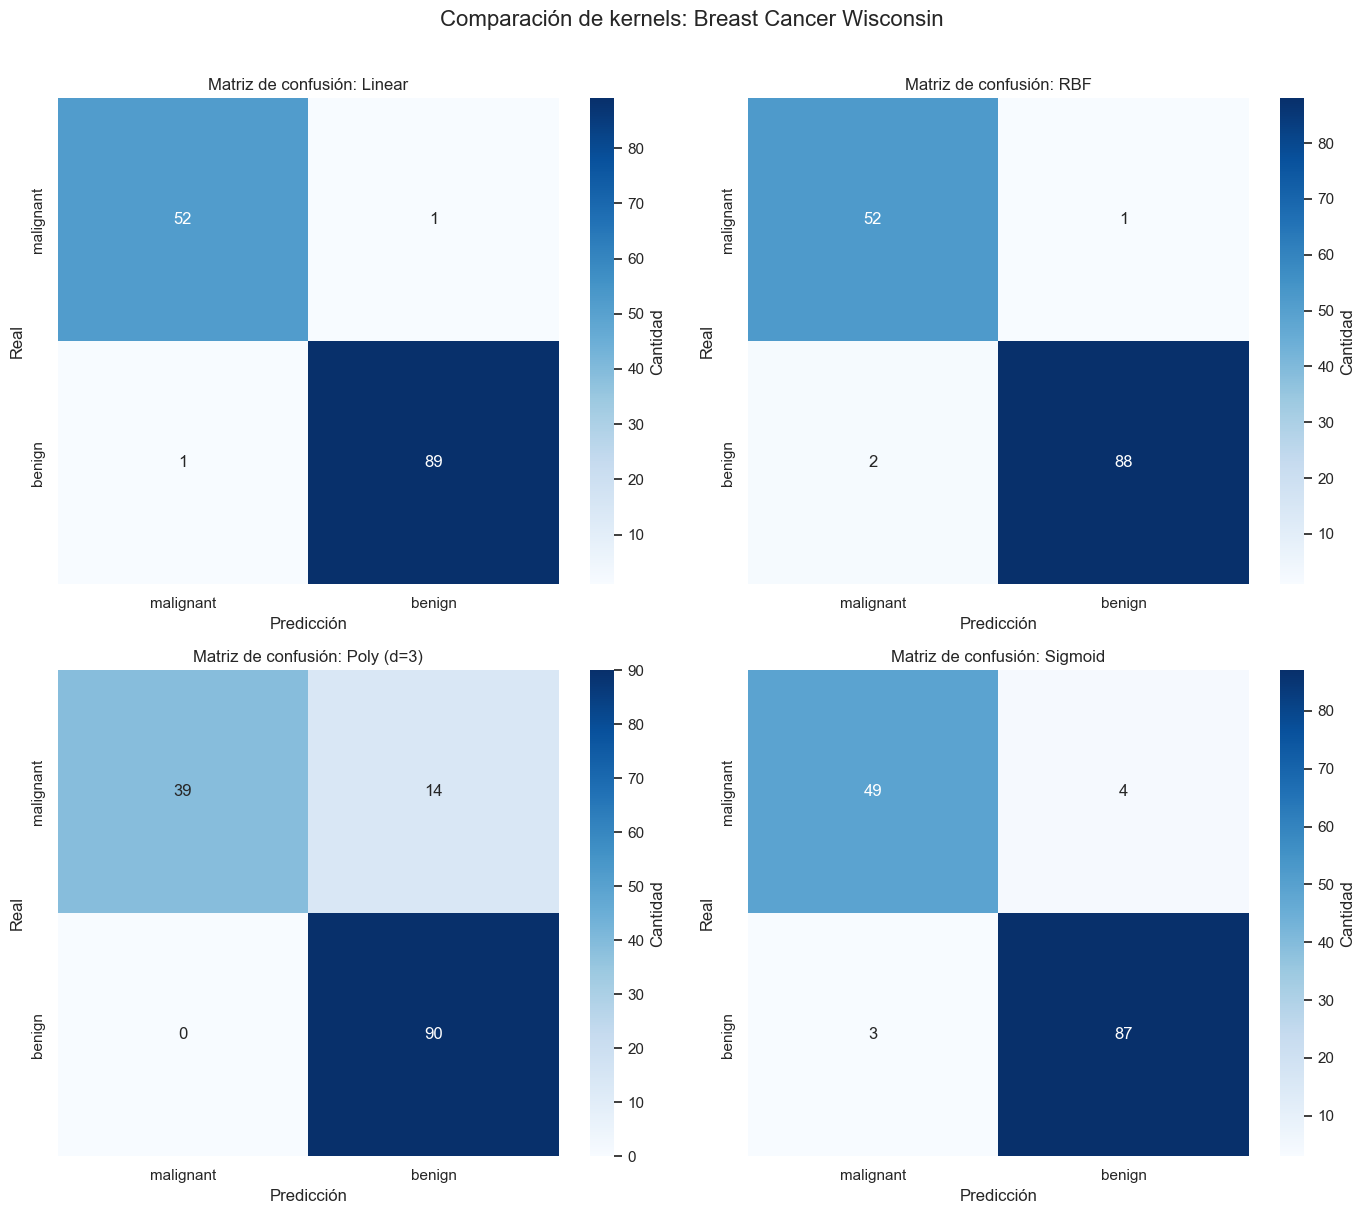


Tabla comparativa de métricas:
    Kernel  Accuracy  Precision   Recall  F1-Score  ROC-AUC
    Linear  0.986014   0.988889 0.988889  0.988889 0.997275
       RBF  0.979021   0.988764 0.977778  0.983240 0.996855
Poly (d=3)  0.902098   0.865385 1.000000  0.927835 0.996436
   Sigmoid  0.951049   0.956044 0.966667  0.961326 0.995178


In [8]:
# Entrenamiento y evaluación sistemática
kernels_real = {
    'Linear': SVC(kernel='linear', C=1.0, probability=True, random_state=42),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Poly (d=3)': SVC(kernel='poly', degree=3, C=1.0, gamma='scale', probability=True, random_state=42),
    'Sigmoid': SVC(kernel='sigmoid', C=1.0, gamma='scale', probability=True, random_state=42)
}

metrics_rows = []

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(kernels_real.items()):
    model.fit(X_train_bc_s, y_train_bc)
    y_pred = model.predict(X_test_bc_s)
    y_prob = model.predict_proba(X_test_bc_s)[:, 1]

    metrics_rows.append({
        'Kernel': name,
        'Accuracy': accuracy_score(y_test_bc, y_pred),
        'Precision': precision_score(y_test_bc, y_pred),
        'Recall': recall_score(y_test_bc, y_pred),
        'F1-Score': f1_score(y_test_bc, y_pred),
        'ROC-AUC': roc_auc_score(y_test_bc, y_prob)
    })

    # Matriz de confusión con Seaborn
    cm = confusion_matrix(y_test_bc, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=data.target_names, yticklabels=data.target_names,
                cbar_kws={'label': 'Cantidad'})
    axes[idx].set_title(f'Matriz de confusión: {name}', fontsize=12)
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')

plt.suptitle('Comparación de kernels: Breast Cancer Wisconsin', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
metrics_df = pd.DataFrame(metrics_rows)
print('\nTabla comparativa de métricas:')
print(metrics_df.to_string(index=False))


In [9]:
# Gráfico interactivo con Altair: comparación de métricas por kernel
metrics_long = metrics_df.melt(id_vars=['Kernel'], var_name='Métrica', value_name='Valor')

chart = alt.Chart(metrics_long).mark_bar(cornerRadiusEnd=4).encode(
    x=alt.X('Kernel:N', sort=metrics_df['Kernel'].tolist(), title='Kernel'),
    y=alt.Y('Valor:Q', title='Valor de la métrica', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Kernel:N', legend=None),
    column=alt.Column('Métrica:N', title='Métrica de evaluación'),
    tooltip=['Kernel', 'Métrica', alt.Tooltip('Valor:Q', format='.4f')]
).properties(
    width=120,
    height=200
)

chart = chart.configure_header(
    titleFontSize=12,
    labelFontSize=11
).configure_axis(
    labelFontSize=11,
    titleFontSize=12
)

chart


alt.Chart(...)

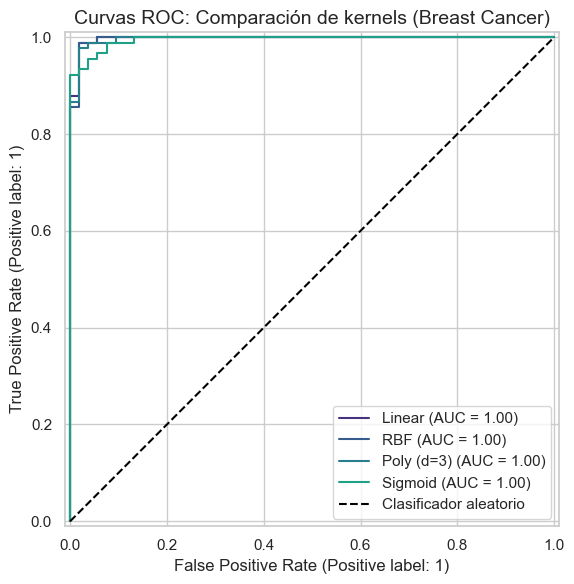

In [10]:
# Curvas ROC comparativas con matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in kernels_real.items():
    y_prob = model.predict_proba(X_test_bc_s)[:, 1]
    RocCurveDisplay.from_predictions(y_test_bc, y_prob, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
ax.set_title('Curvas ROC: Comparación de kernels (Breast Cancer)', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Conclusiones

1. **Los kernels transforman el espacio** de características sin calcular explícitamente la transformación, haciendo factible la clasificación de problemas no lineales.
2. **El kernel RBF es el más versátil**: funciona bien en una amplia gama de problemas sin necesidad de asumir una forma particular de la frontera.
3. **El kernel lineal sigue siendo útil** cuando la dimensionalidad es alta o cuando sabemos que la separación es aproximadamente lineal (eficiencia + interpretabilidad).
4. **La optimización de hiperparámetros (C, gamma) es crítica**: un `GridSearchCV` sistemático evita tanto el subajuste como el sobreajuste.
5. **La evaluación debe ser multi-métrica**: accuracy sola puede ser engañosa en datasets desbalanceados; precision, recall, F1 y ROC-AUC dan una visión completa.

---
**Referencias**
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.
- Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- VanderPlas, J. (2016). *Python Data Science Handbook*. O'Reilly Media.
